Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

In [7]:

path = "./wine.data"
columns = [
    "class",
    "alcohol",
    "malic_acid",
    "ash",
    "alcalinity_of_ash",
    "magnesium",
    "total_phenols",
    "flavanoids",
    "nonflavanoid_phenols",
    "proanthocyanins",
    "color_intensity",
    "hue",
    "od280_od315",
    "proline"
]

# features = columns.remove("class")

df = pd.read_csv(path, header=None, names=columns)

rows, cols = df.shape
print(f"Rows: {rows}, Columns: {cols}")

stats = df.drop("class", axis=1).agg(["mean", "std"])
print(stats)
print(df.head())


Rows: 178, Columns: 14
        alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
mean  13.000618    2.336348  2.366517          19.494944  99.741573   
std    0.811827    1.117146  0.274344           3.339564  14.282484   

      total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
mean       2.295112    2.029270              0.361854         1.590899   
std        0.625851    0.998859              0.124453         0.572359   

      color_intensity       hue  od280_od315     proline  
mean         5.058090  0.957449     2.611685  746.893258  
std          2.318286  0.228572     0.709990  314.907474  
   class  alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  \
0      1    14.23        1.71  2.43               15.6        127   
1      1    13.20        1.78  2.14               11.2        100   
2      1    13.16        2.36  2.67               18.6        101   
3      1    14.37        1.95  2.50               16.8        113   
4      1    13.24 

In [10]:
df.info()
print("Total number of missing values: ", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 178 non-null    int64  
 1   alcohol               178 non-null    float64
 2   malic_acid            178 non-null    float64
 3   ash                   178 non-null    float64
 4   alcalinity_of_ash     178 non-null    float64
 5   magnesium             178 non-null    int64  
 6   total_phenols         178 non-null    float64
 7   flavanoids            178 non-null    float64
 8   nonflavanoid_phenols  178 non-null    float64
 9   proanthocyanins       178 non-null    float64
 10  color_intensity       178 non-null    float64
 11  hue                   178 non-null    float64
 12  od280_od315           178 non-null    float64
 13  proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
Total number of missing val

Z-Score Normalization

In [14]:
features = df.drop("class", axis=1)
# compute z-score
df_z = (features - features.mean()) / features.std()
df_z["class"] = df["class"]
print(df_z.head())

    alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0  1.514341   -0.560668  0.231400          -1.166303   1.908522   
1  0.245597   -0.498009 -0.825667          -2.483841   0.018094   
2  0.196325    0.021172  1.106214          -0.267982   0.088110   
3  1.686791   -0.345835  0.486554          -0.806975   0.928300   
4  0.294868    0.227053  1.835226           0.450674   1.278379   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0       0.806722    1.031908             -0.657708         1.221438   
1       0.567048    0.731565             -0.818411        -0.543189   
2       0.806722    1.212114             -0.497005         2.129959   
3       2.484437    1.462399             -0.979113         1.029251   
4       0.806722    0.661485              0.226158         0.400275   

   color_intensity       hue  od280_od315   proline  class  
0         0.251009  0.361158     1.842721  1.010159      1  
1        -0.292496  0.404908     1.110317  0.962

In [15]:
df_z.mean()
df_z.std()

alcohol                 1.000000
malic_acid              1.000000
ash                     1.000000
alcalinity_of_ash       1.000000
magnesium               1.000000
total_phenols           1.000000
flavanoids              1.000000
nonflavanoid_phenols    1.000000
proanthocyanins         1.000000
color_intensity         1.000000
hue                     1.000000
od280_od315             1.000000
proline                 1.000000
class                   0.775035
dtype: float64

Min-Max Normalisation

In [16]:
features = df.drop("class", axis=1)
# apply min-max scaling
df_minmax = (features - features.min()) / (features.max() - features.min())
df_minmax["class"] = df["class"]
print(df_minmax.head())

    alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0  0.842105    0.191700  0.572193           0.257732   0.619565   
1  0.571053    0.205534  0.417112           0.030928   0.326087   
2  0.560526    0.320158  0.700535           0.412371   0.336957   
3  0.878947    0.239130  0.609626           0.319588   0.467391   
4  0.581579    0.365613  0.807487           0.536082   0.521739   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0       0.627586    0.573840              0.283019         0.593060   
1       0.575862    0.510549              0.245283         0.274448   
2       0.627586    0.611814              0.320755         0.757098   
3       0.989655    0.664557              0.207547         0.558360   
4       0.627586    0.495781              0.490566         0.444795   

   color_intensity       hue  od280_od315   proline  class  
0         0.372014  0.455285     0.970696  0.561341      1  
1         0.264505  0.463415     0.780220  0.550

In [17]:
print("min:\n", df_minmax.min(), "\n")
print("max:\n", df_minmax.max(), "\n")

min:
 alcohol                 0.0
malic_acid              0.0
ash                     0.0
alcalinity_of_ash       0.0
magnesium               0.0
total_phenols           0.0
flavanoids              0.0
nonflavanoid_phenols    0.0
proanthocyanins         0.0
color_intensity         0.0
hue                     0.0
od280_od315             0.0
proline                 0.0
class                   1.0
dtype: float64 

max:
 alcohol                 1.0
malic_acid              1.0
ash                     1.0
alcalinity_of_ash       1.0
magnesium               1.0
total_phenols           1.0
flavanoids              1.0
nonflavanoid_phenols    1.0
proanthocyanins         1.0
color_intensity         1.0
hue                     1.0
od280_od315             1.0
proline                 1.0
class                   3.0
dtype: float64 



EDA!

In [18]:
summary = df.drop("class", axis=1).describe().T
print(summary)

                      count        mean         std     min       25%  \
alcohol               178.0   13.000618    0.811827   11.03   12.3625   
malic_acid            178.0    2.336348    1.117146    0.74    1.6025   
ash                   178.0    2.366517    0.274344    1.36    2.2100   
alcalinity_of_ash     178.0   19.494944    3.339564   10.60   17.2000   
magnesium             178.0   99.741573   14.282484   70.00   88.0000   
total_phenols         178.0    2.295112    0.625851    0.98    1.7425   
flavanoids            178.0    2.029270    0.998859    0.34    1.2050   
nonflavanoid_phenols  178.0    0.361854    0.124453    0.13    0.2700   
proanthocyanins       178.0    1.590899    0.572359    0.41    1.2500   
color_intensity       178.0    5.058090    2.318286    1.28    3.2200   
hue                   178.0    0.957449    0.228572    0.48    0.7825   
od280_od315           178.0    2.611685    0.709990    1.27    1.9375   
proline               178.0  746.893258  314.907474

In [31]:
summary = df_z.drop("class", axis=1).describe().T
print(summary)

                      count          mean  std       min       25%       50%  \
alcohol               178.0 -9.181170e-16  1.0 -2.427388 -0.786027  0.060828   
malic_acid            178.0  0.000000e+00  1.0 -1.428952 -0.656896 -0.421922   
ash                   178.0 -8.070947e-16  1.0 -3.668813 -0.570513 -0.023754   
alcalinity_of_ash     178.0 -7.983626e-17  1.0 -2.663505 -0.687199  0.001514   
magnesium             178.0 -1.995907e-17  1.0 -2.082381 -0.822096 -0.121938   
total_phenols         178.0  3.991813e-17  1.0 -2.101318 -0.882977  0.095690   
flavanoids            178.0 -3.592632e-16  1.0 -1.691200 -0.825211  0.105851   
nonflavanoid_phenols  178.0  3.592632e-16  1.0 -1.862979 -0.738059 -0.175599   
proanthocyanins       178.0 -1.596725e-16  1.0 -2.063214 -0.595603 -0.062721   
color_intensity       178.0  1.995907e-17  1.0 -1.629691 -0.792866 -0.158777   
hue                   178.0  1.995907e-16  1.0 -2.088840 -0.765403  0.033034   
od280_od315           178.0  3.193450e-1

In [32]:
summary = df_minmax.drop("class", axis=1).describe().T
print(summary)

                      count      mean       std  min       25%       50%  \
alcohol               178.0  0.518584  0.213639  0.0  0.350658  0.531579   
malic_acid            178.0  0.315484  0.220780  0.0  0.170455  0.222332   
ash                   178.0  0.538244  0.146708  0.0  0.454545  0.534759   
alcalinity_of_ash     178.0  0.458502  0.172142  0.0  0.340206  0.458763   
magnesium             178.0  0.323278  0.155244  0.0  0.195652  0.304348   
total_phenols         178.0  0.453487  0.215811  0.0  0.262931  0.474138   
flavanoids            178.0  0.356386  0.210730  0.0  0.182489  0.378692   
nonflavanoid_phenols  178.0  0.437460  0.234818  0.0  0.264151  0.396226   
proanthocyanins       178.0  0.372523  0.180555  0.0  0.264984  0.361199   
color_intensity       178.0  0.322363  0.197806  0.0  0.165529  0.290956   
hue                   178.0  0.388170  0.185831  0.0  0.245935  0.394309   
od280_od315           178.0  0.491460  0.260070  0.0  0.244505  0.553114   
proline     

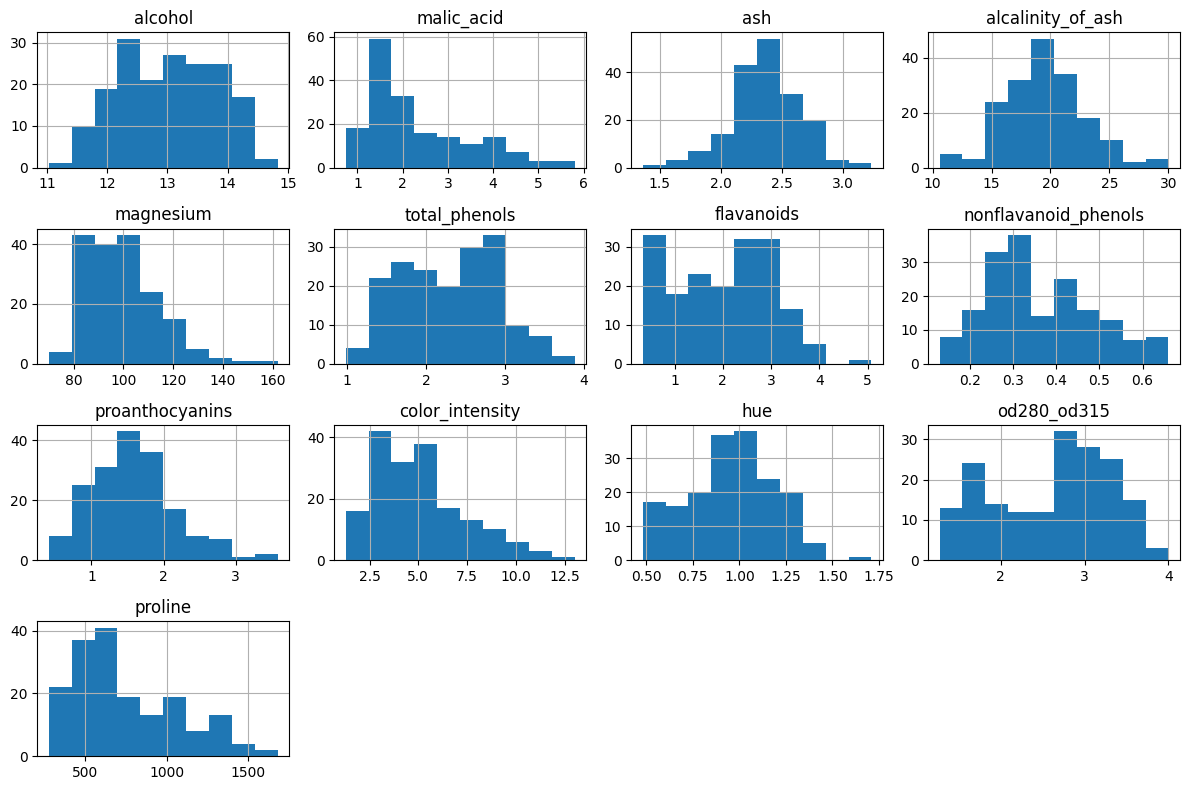

In [12]:
df[df.columns.drop("class")].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

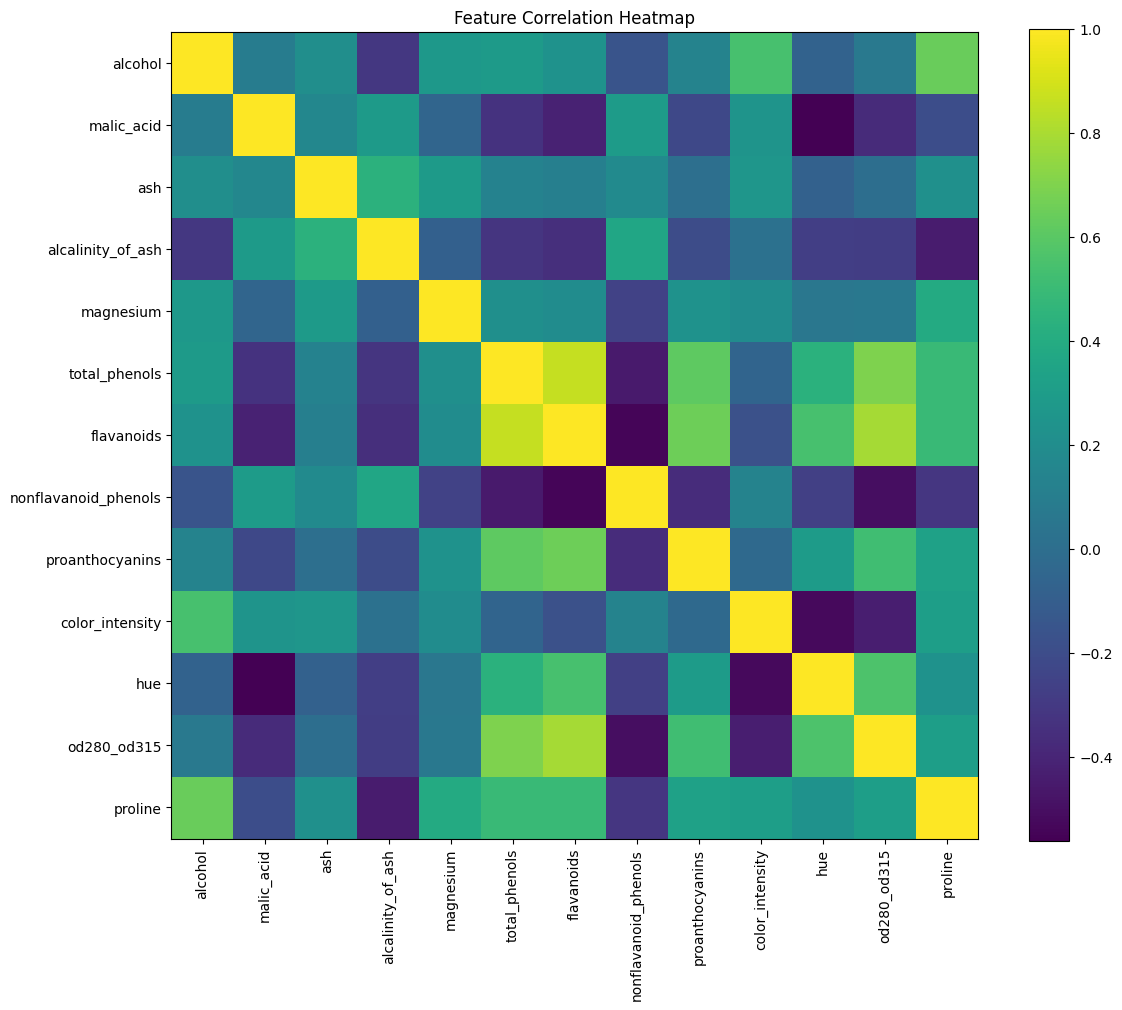

In [35]:
corr = df.drop("class", axis=1).corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

+1  → strong positive relation
 0  → independent-ish
-1  → strong negative relation

In [39]:
corr = df.drop("class", axis=1).corr().abs()
np.fill_diagonal(corr.values, 0)

# flatten to series
corr_flat = corr.unstack()

# sort descending
corr_sorted = corr_flat.sort_values(ascending=False)

# get top 2 pairs (ignore duplicates like (A,B) and (B,A))
seen = set()
top_pairs = []
for (f1, f2), val in corr_sorted.items():
    if (f2, f1) not in seen:
        top_pairs.append((f1, f2, val))
        seen.add((f1, f2))
    if len(top_pairs) == 2:
        break

top_pairs

[('total_phenols', 'flavanoids', 0.8645635000951147),
 ('flavanoids', 'od280_od315', 0.787193901866951)]

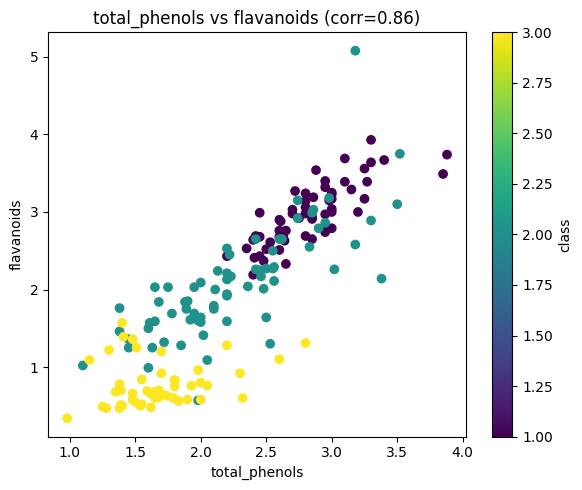

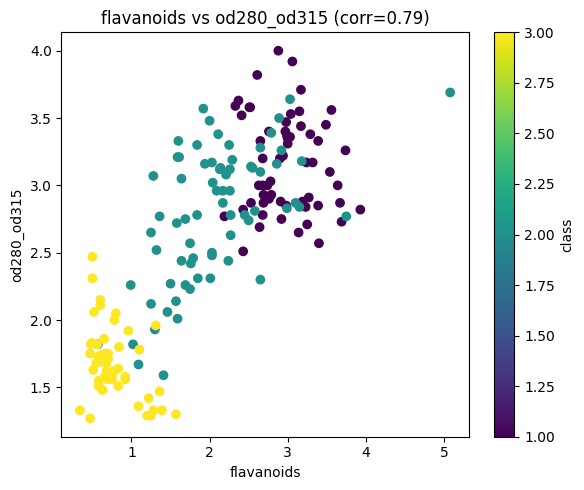

In [40]:
for f1, f2, val in top_pairs:
    plt.figure(figsize=(6,5))
    plt.scatter(df[f1], df[f2], c=df["class"], cmap='viridis')
    plt.xlabel(f1)
    plt.ylabel(f2)
    plt.title(f"{f1} vs {f2} (corr={val:.2f})")
    plt.colorbar(label='class')
    plt.tight_layout()
    plt.show()

Dimensionality Reduction for Visualization

Explained variance ratio: [0.40749485 0.18970352]


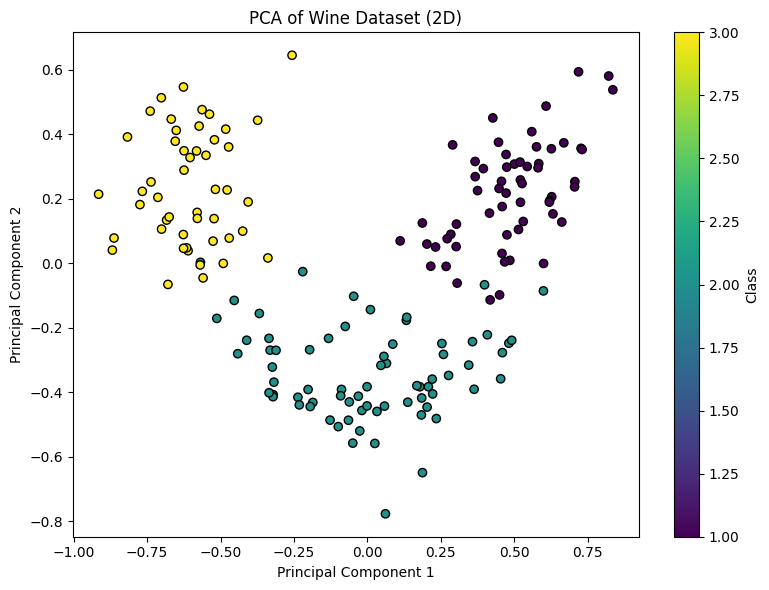

In [24]:
X = df_minmax.drop("class", axis=1).values  # shape: (178, 13)
y = df_minmax["class"].values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)  # shape: (178, 2)

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis', edgecolor='k')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Wine Dataset (2D)")
plt.colorbar(scatter, label="Class")
plt.tight_layout()
plt.show()

Distance Behavior in High-Dimensional Space

In [44]:
X = df_z.drop("class", axis=1).values
# Euclidean distances
dist_euclidean = pdist(X, metric='euclidean')

# Manhattan distances
dist_manhattan = pdist(X, metric='cityblock')

# Cosine distances
dist_cosine = pdist(X, metric='cosine')

for name, d in [("Euclidean", dist_euclidean),
                ("Manhattan", dist_manhattan),
                ("Cosine", dist_cosine)]:
    print(f"{name} distances:")
    print(f"Mean: {d.mean():.3f}")
    print(f"Std : {d.std():.3f}")
    print(f"Min : {d.min():.3f}")
    print(f"Max : {d.max():.3f}")
    print("-"*30)

Euclidean distances:
Mean: 4.892
Std : 1.437
Min : 1.161
Max : 11.180
------------------------------
Manhattan distances:
Mean: 14.590
Std : 4.693
Min : 3.187
Max : 31.911
------------------------------
Cosine distances:
Mean: 1.004
Std : 0.437
Min : 0.045
Max : 1.918
------------------------------


CV: Coefficient Variation
In high-dimensional spaces, distances tend to “concentrate” around the mean.
If CV is small (e.g., 0.05 → 5%), it means almost all distances are very close to the mean → hard to distinguish points based on distance.
If CV is moderate/large (e.g., 0.3–0.5), distances are more spread out → clustering can still work.

1- Euclidean: distances moderately spread (CV ~0.29). Not terrible, but some concentration.
2- Manhattan: slightly more spread (CV ~0.32). Good separation.
3- Cosine: largest relative spread (CV ~0.44). Points are more distinguishable in terms of angle/direction.

This suggests that Cosine separates points more clearly in terms of orientation of features.
The minimum is very small (almost identical orientation), the maximum almost 2 (opposite directions), showing diversity in “shape” of points.

Impact of Feature Scaling on K-Means

In [25]:
datasets = {
    "Raw": df.drop("class", axis=1).values,
    "Z-score": df_z.drop("class", axis=1).values,
    "Min-Max": df_minmax.drop("class", axis=1).values
}

results = []

for name, X in datasets.items():
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X, labels)
    
    results.append({
        "Dataset": name,
        "Inertia": inertia,
        "Silhouette": silhouette
    })

results_df = pd.DataFrame(results)
print(results_df)

   Dataset       Inertia  Silhouette
0      Raw  2.370690e+06    0.571138
1  Z-score  1.270749e+03    0.284859
2  Min-Max  4.896052e+01    0.300894


K-Means Implementation from Scratch

In [27]:
class KMeansCustom:
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape

        indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        centroids = X[indices]

        for iteration in range(self.max_iter):
            distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
            labels = np.argmin(distances, axis=1)

            new_centroids = np.array([X[labels == i].mean(axis=0) if np.any(labels==i) else centroids[i] 
                                      for i in range(self.n_clusters)])

            if np.all(np.linalg.norm(new_centroids - centroids, axis=1) < self.tol):
                break

            centroids = new_centroids

        self.centroids = centroids
        self.labels_ = labels
        self.n_iter_ = iteration + 1
        self.inertia_ = sum(np.sum((X[labels == i] - centroids[i])**2) for i in range(self.n_clusters))
        return self
    
X = df_minmax.drop("class", axis=1).values

start_time = time.time()
kmeans_custom = KMeansCustom(n_clusters=3, max_iter=300, random_state=42)
kmeans_custom.fit(X)
custom_time = time.time() - start_time

print("Custom K-Means:")
print("Inertia:", kmeans_custom.inertia_)
print("Iterations:", kmeans_custom.n_iter_)
print("Runtime (s):", round(custom_time, 4))

start_time = time.time()
kmeans_sklearn = KMeans(n_clusters=3, max_iter=300, n_init=10, random_state=42)
kmeans_sklearn.fit(X)
sklearn_time = time.time() - start_time

print("\nscikit-learn K-Means:")
print("Inertia:", kmeans_sklearn.inertia_)
print("Iterations:", kmeans_sklearn.n_iter_)
print("Runtime (s):", round(sklearn_time, 4))

Custom K-Means:
Inertia: 48.97029115513918
Iterations: 8
Runtime (s): 0.0031

scikit-learn K-Means:
Inertia: 48.9605171366765
Iterations: 4
Runtime (s): 0.0205


Hierarchical Clustering Stability Analysis

In [28]:
X = df_z.drop("class", axis=1).values
linkage_methods = ["single", "complete", "average", "ward"]
cophenetic_scores = {}

distances = pdist(X, metric='euclidean')

for method in linkage_methods:
    Z = linkage(X, method=method)
    c, _ = cophenet(Z, distances)
    cophenetic_scores[method] = c

cophenetic_scores

{'single': np.float64(0.5436231199247621),
 'complete': np.float64(0.5916829459078576),
 'average': np.float64(0.7590840545998375),
 'ward': np.float64(0.6623487206613263)}

In [31]:
ranked_methods = sorted(cophenetic_scores.items(), key=lambda x: x[1], reverse=True)
print("Linkage methods ranked by stability:")
for i, (method, score) in enumerate(ranked_methods, 1):
    print(f"{i}. {method} : {score:.4f}")

Linkage methods ranked by stability:
1. average : 0.7591
2. ward : 0.6623
3. complete : 0.5917
4. single : 0.5436


In [32]:
most_stable_method = ranked_methods[0][0]
print("Most stable linkage method:", most_stable_method)

Most stable linkage method: average


Automated Density-Based Clustering

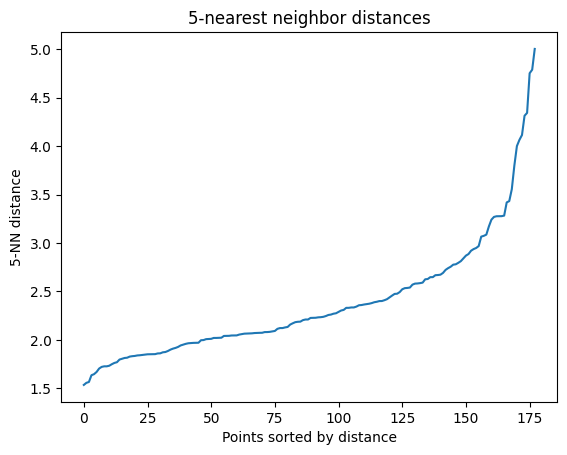

In [41]:
# X = your Z-score normalized data
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(df_z)
distances, indices = nbrs.kneighbors(df_z)
# Take the distance to the k-th nearest neighbor for each point
k_distances = distances[:, k-1]  # zero-indexed

k_distances_sorted = np.sort(k_distances)
plt.plot(k_distances_sorted)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-NN distance")
plt.title(f"{k}-nearest neighbor distances")
plt.show()

In [42]:
epsilon = k_distances.mean() + k_distances.std()
print("Estimated epsilon:", epsilon)

Estimated epsilon: 3.0048055712308877


In [43]:
min_samples = k  # often set equal to k
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
labels = dbscan.fit_predict(df_z)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print(f"Detected clusters: {n_clusters}")
print(f"Noise points: {n_noise}")

Detected clusters: 1
Noise points: 10


1 cluster → almost all points are grouped together.
6 noise points → a few points are considered outliers.

Problem: DBSCAN is supposed to find multiple dense clusters, but here it sees the whole dataset as one big cluster.

This usually means:
ε is too large → all points are within that distance of each other.
High-dimensional data → distances are “concentrated” (we saw this with Euclidean / Cosine distances). In high dimensions, DBSCAN struggles because there’s no clear dense region

Solution: using PCA

In [48]:
pca = PCA(n_components=2)  # or 3
X_pca = pca.fit_transform(df_z)

nbrs = NearestNeighbors(n_neighbors=5).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
k_distances = distances[:, 4]
epsilon = k_distances.mean() + k_distances.std()
print("Estimated epsilon:", epsilon)

dbscan = DBSCAN(eps=epsilon, min_samples=5)
labels = dbscan.fit_predict(X_pca)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print(f"Detected clusters: {n_clusters}")
print(f"Noise points: {n_noise}")

Estimated epsilon: 0.675159736194372
Detected clusters: 2
Noise points: 7


Fully Automated Clustering System

In [103]:
def preprocess_data(X, method="zscore", reduce_dim=False, n_components=2):
    # Scaling
    if method == "zscore":
        scaler = StandardScaler()
    elif method == "minmax":
        scaler = MinMaxScaler()
    else:
        raise ValueError("Unknown scaling method")
    X_scaled = scaler.fit_transform(X)
    
    # Optional PCA
    if reduce_dim:
        pca = PCA(n_components=n_components, random_state=42)
        X_scaled = pca.fit_transform(X_scaled)
    
    return X_scaled

def estimate_eps(X, k=5):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(X)
    distances, _ = neighbors_fit.kneighbors(X)
    k_distances = np.sort(distances[:, k-1])
    # Use percentile heuristic
    q3 = np.percentile(k_distances, 75)
    q1 = np.percentile(k_distances, 25)
    iqr = q3 - q1
    epsilon = q3 + 1.5*iqr
    return epsilon

def evaluate_algorithms(X, cluster_range=(2,6), dbscan_k=5):
    results = []
    
    # --- K-Means ---
    for k in range(cluster_range[0], cluster_range[1]+1):
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        score = silhouette_score(X, labels)
        results.append({
            "algorithm": "KMeans",
            "params": {"n_clusters": k},
            "labels": labels,
            "score": score
        })
    
    # --- Agglomerative (Ward) ---
    for k in range(cluster_range[0], cluster_range[1]+1):
        agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels = agg.fit_predict(X)
        score = silhouette_score(X, labels)
        results.append({
            "algorithm": "Agglomerative",
            "params": {"n_clusters": k, "linkage":"ward"},
            "labels": labels,
            "score": score
        })
    
    # --- DBSCAN ---
    eps = estimate_eps(X, k=dbscan_k)
    db = DBSCAN(eps=eps, min_samples=dbscan_k)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        score = silhouette_score(X, labels)
    else:
        score = -1  # silhouette undefined or meaningless
    results.append({
        "algorithm": "DBSCAN",
        "params": {"eps": eps, "min_samples": dbscan_k},
        "labels": labels,
        "score": score
    })
    
    return results

def select_best(results):
    best = max(results, key=lambda x: x["score"])
    summary = {
        "algorithm": best["algorithm"],
        "parameters": best["params"],
        "silhouette_score": best["score"],
        "num_clusters": len(set(best["labels"])) - (1 if -1 in best["labels"] else 0),
        "num_noise": list(best["labels"]).count(-1) if best["algorithm"]=="DBSCAN" else 0
    }
    return summary

X = df.drop("class", axis=1).values  # original features

# Preprocess (z-score + optional PCA for DBSCAN)
X_proc = preprocess_data(X, method="zscore", reduce_dim=False)  # no PCA yet

# Evaluate all algorithms
results = evaluate_algorithms(X_proc, cluster_range=(2,6), dbscan_k=5)

# Select best automatically
best_summary = select_best(results)
print(best_summary)

{'algorithm': 'KMeans', 'parameters': {'n_clusters': 3}, 'silhouette_score': 0.2848589191898987, 'num_clusters': 3, 'num_noise': 0}


Subspace Clustering via PCA

PCA 2D → Silhouette Score: 0.561
PCA 3D → Silhouette Score: 0.453
PCA 4D → Silhouette Score: 0.407
PCA 5D → Silhouette Score: 0.369
PCA 6D → Silhouette Score: 0.346
PCA 7D → Silhouette Score: 0.328
PCA 8D → Silhouette Score: 0.315
PCA 9D → Silhouette Score: 0.306
PCA 10D → Silhouette Score: 0.299

Optimal dimensionality: 2 (Silhouette: 0.561)


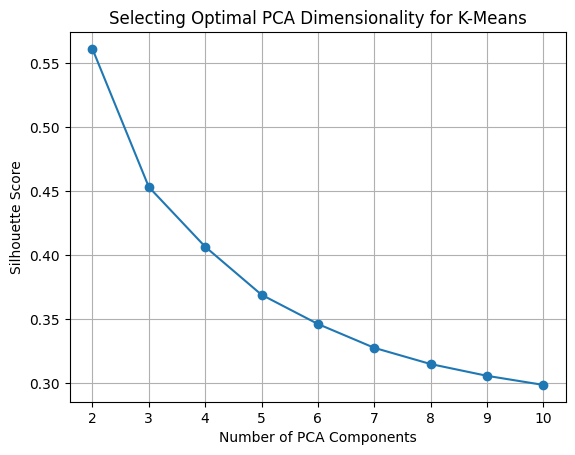

In [106]:
X = df.drop("class", axis=1).values  # original features
X_scaled = StandardScaler().fit_transform(X)  # standardize

best_score = -1
best_n_components = None
results = []

for n_comp in range(2, 11):  # 2 to 10
    # Apply PCA
    pca = PCA(n_components=n_comp, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    # K-Means with k=3
    kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    
    # Compute silhouette score
    score = silhouette_score(X_pca, labels)
    
    # Store results
    results.append((n_comp, score))
    
    # Track best
    if score > best_score:
        best_score = score
        best_n_components = n_comp

# Print results
for n_comp, score in results:
    print(f"PCA {n_comp}D → Silhouette Score: {score:.3f}")

print(f"\nOptimal dimensionality: {best_n_components} (Silhouette: {best_score:.3f})")

n_components_list, scores = zip(*results)
plt.plot(n_components_list, scores, marker='o')
plt.xlabel("Number of PCA Components")
plt.ylabel("Silhouette Score")
plt.title("Selecting Optimal PCA Dimensionality for K-Means")
plt.grid(True)
plt.show()